In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import  ncx2
import pandas as pd
from numba import  njit

# Примеры

In [2]:
class StochasticProcess:
    def __init__(self, params, T, Nx, Nt, init_state = None):
        self.params = params
        self.T = T
        self.Nx = Nx # Number of trajectories
        self.Nt = Nt # Number of discretization steps
        self.init_state = init_state

    #Wiener Process by default
    #use @staticmethod for numba compatibility with @njit
    @staticmethod
    @njit
    def bxt(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return 1

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return 0

    @staticmethod
    @njit
    def bxt_xx(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt_xx(x, t, params):
        return 0

    @staticmethod
    @njit
    def bxt_t(x, t, params):
        return 0

    def DefaultInitState(self):
        return np.zeros(self.Nx)

    def EulerSolution(self, dwt = None):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if dwt is None:
            dwt = np.random.normal(0, 1, size = (self.Nt, self.Nx)) * np.sqrt(dt)

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + self.bxt(x_data[i - 1], t_data[i - 1], self.params) * dt +\
                        self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) * dwt[i - 1]
        return t_data, x_data

    def Milstein2Solution(self, dwt = None):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if dwt is None:
            dwt = np.random.normal(0, 1, size = (self.Nt, self.Nx)) * np.sqrt(dt)

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + (self.bxt(x_data[i - 1], t_data[i - 1], self.params) - 1/2 * self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) * self.sigmaxt_x(x_data[i - 1], t_data[i - 1], self.params)) * dt +\
                        self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) * dwt[i - 1] + 1/2 * self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) * self.sigmaxt_x(x_data[i - 1], t_data[i - 1], self.params) * dwt[i - 1]**2 +\
                        (1/2 * self.bxt(x_data[i - 1], t_data[i - 1], self.params) * self.sigmaxt_x(x_data[i - 1], t_data[i - 1], self.params) + 1/2 * self.bxt_x(x_data[i - 1], t_data[i - 1], self.params) * self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) +\
                        1/4 * self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params)**2 * self.sigmaxt_xx(x_data[i - 1], t_data[i - 1], self.params)) * dt * dwt[i - 1] +\
                        (1/2 * self.bxt(x_data[i - 1], t_data[i - 1], self.params) * self.bxt_x(x_data[i - 1], t_data[i - 1], self.params) + 1/4 * self.bxt_xx(x_data[i - 1], t_data[i - 1], self.params) * self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params)**2) * dt**2
        return t_data, x_data


class CIRprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

    # params = [theta1, theta2, theta3]
    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] - params[1] * x

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[2] * np.sqrt(np.maximum(x,0))

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return -params[1]

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return params[2] * 1/2 * 1/np.sqrt(np.maximum(x,0))

    @staticmethod
    @njit
    def sigmaxt_xx(x, t, params):
        return -params[2] * 1/4 * 1/np.maximum(x,0)**(3/2)

    def DefaultInitState(self):
        return self.params[0] / self.params[1] * np.ones(self.Nx)

    def ExactSolution(self, dwt = None):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        if dwt is None:
            dwt = np.random.normal(0, 1, size = (self.Nt, self.Nx)) * np.sqrt(dt)

        Ito_integral_sum = np.zeros(self.Nx)
        for i in range(1, self.Nt + 1):
            Determinated_part = (x_data[0] - theta1 / theta2) * np.exp(-theta2 * t_data[i]) + theta1/theta2
            #avoiding exp overflow
            Ito_integral_sum = (Ito_integral_sum + theta3 * np.sqrt(np.maximum(x_data[i - 1], 0)) * dwt[i - 1]) * np.exp(-theta2 * dt)
            x_data[i] = Determinated_part + Ito_integral_sum
        return t_data, x_data

    def StationaryState(self):
        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        k = theta2
        theta = theta1 / theta2
        sigma = theta3

        c = 2 * k / (sigma**2)
        u = 0
        q = 2 * k * theta / sigma**2 - 1

        return ncx2.rvs(2 * q + 2, 2 * u, size = self.Nx) / (2 * c)

    def ProcessDistribution(self, x, t, x0, t0):
        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        k = theta2
        theta = theta1 / theta2
        sigma = theta3

        c = 2 * k / (sigma**2 * (1 - np.exp(-k * (t - t0))))
        u = c * x0 * np.exp(-k * (t - t0))
        #v = c * x
        q = 2 * k * theta / sigma**2 - 1
        return ncx2.pdf(2 * c * x, 2 * q + 2, 2 * u) * (2 * c) #2c is normalazing constant

    def StationaryDistribution(self, x):
        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        k = theta2
        theta = theta1 / theta2
        sigma = theta3

        c = 2 * k / (sigma**2)
        u = 0
        q = 2 * k * theta / sigma**2 - 1
        return ncx2.pdf(2 * c * x, 2 * q + 2, 2 * u) * (2 * c)

Execise 1. Simulate a Cox-Ingersoll-Ross (CIR) model
$$
dX_t = (\theta_1 - \theta_2 X_t)dt + \theta_3 \sqrt{X_t}dW_t
$$
with $\theta = (6, 2, 1)$, and choose the bandwidth according to Scott’s rule and implement the non-parametric kernel estimation for stationary density of the CIR model.

Plot in a graph the true stationary density against the estimated one for
*   $n=1000$, $\Delta_n=1$,
*   $n=15000$, $\Delta_n=0.01$.



In [3]:
def StationaryDistributionKernelEstimator(x, x_data, delta = None):
    n = len(x_data)
    m = 1

    hn = 1

    if delta is None:
        hn = np.std(x_data) * n**(-1 / (m + 4))
    else:
        hn = delta

    pi = np.zeros(len(x))

    for j in range(0, len(x)):
        K = 1/np.sqrt(2 * np.pi) * np.exp(-1/2 * (x[j] - x_data)**2 / hn**2)

        pi[j] = 1 / (n * hn) * np.sum(K)

    return pi

In [4]:
'''Расчёт на 1 траектрии
Для обеспечения стационарности задаём T очень большим. T/Nt = delta t - шаг дискретизации по времени
'''

Nx = 1
Nt = 100000
T = 1000

params_CIR = [6, 2, 1]

CIRp = CIRprocess(params_CIR, T, Nx, Nt)
CIRp.init_state = CIRp.StationaryState()
t_data, x_data_CIR = CIRp.ExactSolution()

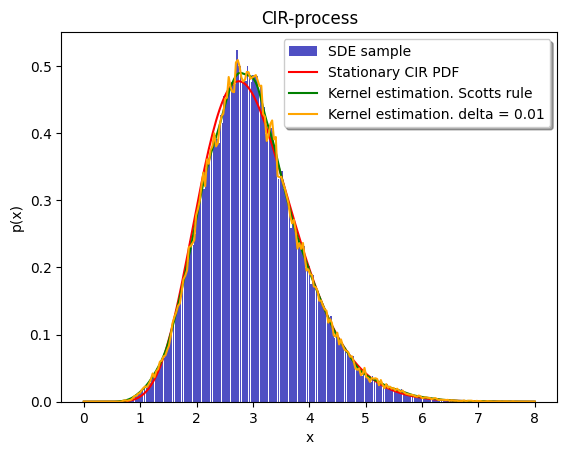

In [5]:
n = np.random.randint(0, Nt)
fig, ax = plt.subplots()
x_data = np.linspace(0, 8, 250)

i = np.random.randint(0, Nt)

n, bins, patches = ax.hist(x_data_CIR.flatten(), bins=x_data, density=True, color='#0504aa', alpha=0.7, rwidth=0.85, label = 'SDE sample')
ax.set_xlabel('x')
ax.set_ylabel('p(x)')
ax.set_title(f'CIR-process', loc = 'center')

ax.plot(x_data, CIRp.StationaryDistribution(x_data), label = 'Stationary CIR PDF', color = 'red')
#ax.plot(x_data, CIRp.ProcessDistribution(x_data, T * i / Nt, x0, 0), label = 'Stationary CIR PDF', color = 'red')

ax.plot(x_data, StationaryDistributionKernelEstimator(x_data, x_data_CIR.flatten()), label = f'Kernel estimation. Scotts rule', color = 'green')

d = 0.01
ax.plot(x_data, StationaryDistributionKernelEstimator(x_data, x_data_CIR.flatten(), delta = d),
        label = f'Kernel estimation. delta = {d}', color = 'orange')

ax.legend(loc = 'upper right', fancybox = True, shadow = True)
plt.show()

In [6]:
'''Расчёт на Nx траектриях
Для обеспечения стационарности задаём число траекторий Nx большим, а так же
в качестве начального состояния задаём стационарное состояние
'''
Nx = 15000
Nt = 300

T = 1

params_CIR = [6, 2, 1]

CIRp = CIRprocess(params_CIR, T, Nx, Nt)
CIRp.init_state = CIRp.StationaryState()
t_data, x_data_CIR = CIRp.ExactSolution()

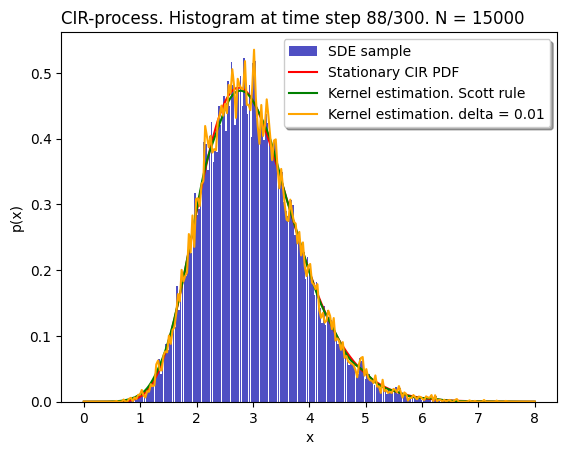

In [7]:
n = np.random.randint(0, Nt)
fig, ax = plt.subplots()
x_data = np.linspace(0, 8, 250)

i = np.random.randint(0, Nt)

n, bins, patches = ax.hist(x_data_CIR[i], bins=x_data, density=True, color='#0504aa', alpha=0.7, rwidth=0.85, label = 'SDE sample')
ax.set_xlabel('x')
ax.set_ylabel('p(x)')
ax.set_title(f'CIR-process. Histogram at time step {i}/{Nt}. N = {Nx}', loc = 'left')

ax.plot(x_data, CIRp.StationaryDistribution(x_data), label = 'Stationary CIR PDF', color = 'red')
#ax.plot(x_data, CIRp.ProcessDistribution(x_data, T * i / Nt, x0, 0), label = 'Stationary CIR PDF', color = 'red')

ax.plot(x_data, StationaryDistributionKernelEstimator(x_data, x_data_CIR[i]), label = f'Kernel estimation. Scott rule', color = 'green')

d = 0.01
ax.plot(x_data, StationaryDistributionKernelEstimator(x_data, x_data_CIR[i], delta = d),
        label = f'Kernel estimation. delta = {d}', color = 'orange')

ax.legend(loc = 'upper right', fancybox = True, shadow = True)
plt.show()

Task. Estimate the quality of the obtained approximations with statistical criteria and provide conclusions.

In [8]:
# your code

Task. Study the effect of the bandwidth $h_n$ and the mesh $∆_n$ on the kernel estimator and plot a 3D graph.

In [9]:
# your code

Task 2. Implement a non-parametric drift estimator

$$
\hat{b}_n(x) = \frac{\sum_{i=0}^{n-1} K\left(\frac{x-X_i}{h_n}\right)(X_{i+1}-X_i)} {\Delta_n \sum_{i=0}^{n-1} K\left(\frac{x-X_i}{h_n}\right)}
$$

and diffusion estimator
$$
\hat{\sigma}^2_n(x) = \frac{\sum_{i=0}^{n-1} K\left(\frac{x-X_i}{h_n}\right)(X_{i+1}-X_i)^2} {\Delta_n \sum_{i=0}^{n-1} K\left(\frac{x-X_i}{h_n}\right)}.$$


for the model from previous item and plot two graphs.
Use the

*  Gaussian kernel $K(u) = \frac{1}{\sqrt{2\pi}} \exp \left(-\frac{1}{2}u^2\right)$,
*  Uniform kernel $K(u)=1/2$,
*  Epanechnikov (parabolic) kernel $K(u)=\frac{3}{4}(1-u^2)$.


In [10]:
from typing import Literal

def NormalKernel(z):
    return 1/np.sqrt(2 * np.pi) * np.exp(-1/2 * z**2)

def UniformKernel(z):
    return 1/2 * np.ones_like(z)

def ParabolicKernel(z):
    return 3/4 * (1 - z**2)

def DiffusionKernelEstimator(x, x_data, delta = None, method: Literal['normal', 'uniform', 'parabolic'] = 'normal'):
    n = len(x_data)
    m = 1

    hn = 1

    hn = np.std(x_data) * n**(-1 / (m + 4))

    s2 = np.zeros(len(x))

    for j in range(0, len(x)):
        K1 = 0
        K2 = 0
        z = (x[j] - x_data)**2 / hn**2
        if method == 'normal':
            K = NormalKernel(z)
        elif method == 'uniform':
            K = UniformKernel(z)
        elif method == 'parabolic':
            K = ParabolicKernel(z)
        else:
            raise ValueError(f"method = {method} not implemented")

        K1 = np.sum(K[0:n-1] * (x_data[1:] - x_data[0:n-1])**2)
        K2 = np.sum(K)
        if K2 == 0:
            s2[j] = 0
        else:
            s2[j] = K1 / K2

    if delta is None:
        delta = 1

    return s2 / delta

def DriftKernelEstimator(x, x_data, delta = None, method: Literal['normal', 'uniform', 'parabolic'] = 'normal'):
    n = len(x_data)
    m = 1

    hn = 1

    hn = np.std(x_data) * n**(-1 / (m + 4))

    s2 = np.zeros(len(x))

    for j in range(0, len(x)):
        K1 = 0
        K2 = 0
        z = (x[j] - x_data)**2 / hn**2
        if method == 'normal':
            K = NormalKernel(z)
        elif method == 'uniform':
            K = UniformKernel(z)
        elif method == 'parabolic':
            K = ParabolicKernel(z)
        else:
            raise ValueError(f"method = {method} not implemented")

        K1 = np.sum(K[0:n-1] * (x_data[1:] - x_data[0:n-1]))
        K2 = np.sum(K)
        if K2 == 0:
            s2[j] = 0
        else:
            s2[j] = K1 / K2

    if delta is None:
        delta = 1

    return s2 / delta

In [11]:
Nx = 1
Nt = 100000

T = 1000

x_data = np.linspace(0, 6, 200)

params_CIR = [6, 2, 1]

CIRp = CIRprocess(params_CIR, T, Nx, Nt)
t_data, x_data_CIR = CIRp.ExactSolution()

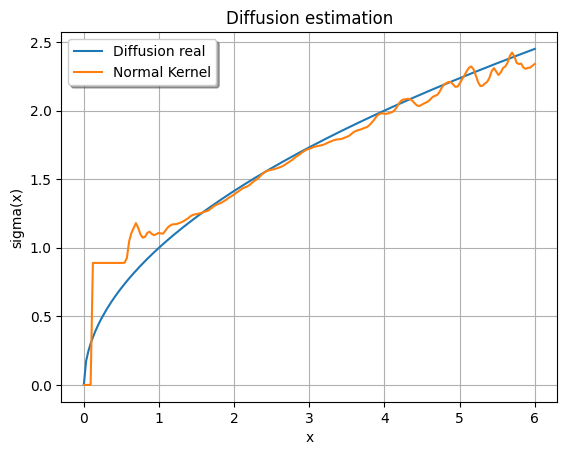

In [12]:
sigma_data = CIRp.sigmaxt(x_data, 0, CIRp.params)

plt.plot(x_data, sigma_data, label = 'Diffusion real')


diffke = DiffusionKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'normal')
plt.plot(x_data, np.sqrt(diffke), label = 'Normal Kernel')

#diffke = DiffusionKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'parabolic')
#plt.plot(x_data, np.sqrt(diffke), label = 'Parabolic Kernel')

#diffke = DiffusionKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'uniform')
#plt.plot(x_data, np.sqrt(diffke), label = 'Uniform Kernel')

plt.title("Diffusion estimation")
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("x")
plt.ylabel("sigma(x)")
plt.grid(True)
plt.show()

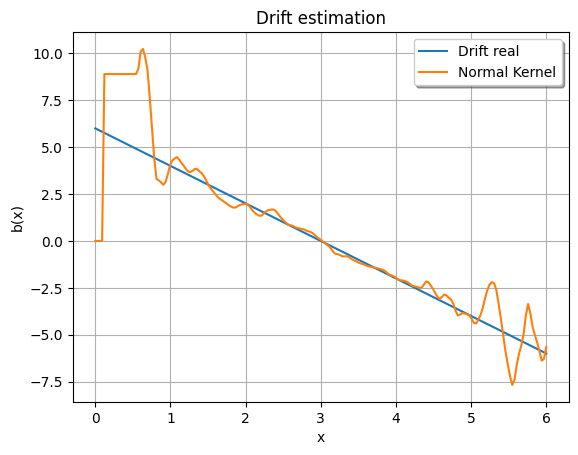

In [13]:
b_data = CIRp.bxt(x_data, 0, CIRp.params)

plt.plot(x_data, b_data, label = 'Drift real')


driftke = DriftKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'normal')
plt.plot(x_data, driftke, label = 'Normal Kernel')

#driftke = DriftKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'parabolic')
#plt.plot(x_data, driftke, label = 'Parabolic Kernel')

#driftke = DriftKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'uniform')
#plt.plot(x_data, driftke, label = 'Uniform Kernel')

plt.title("Drift estimation")
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("x")
plt.ylabel("b(x)")
plt.grid(True)
plt.show()

# Задачи

Задача 1. Оценивание стационарной плотности ансамбля
1. Для модели CIR или OU сгенерируйте траекторию процесса с большим финальным временем $T$ для достижения стационарного режима.

2. Реализуйте функцию `StationaryDistributionKernelEstimator`.

3. Постройте на одном графике теоретическую стационарную плотность $π(x)$ и три ядерные оценки с использованием различных ядер: гауссовского, равномерного и Епанечникова (параболического).

4. Сделайте выводы.


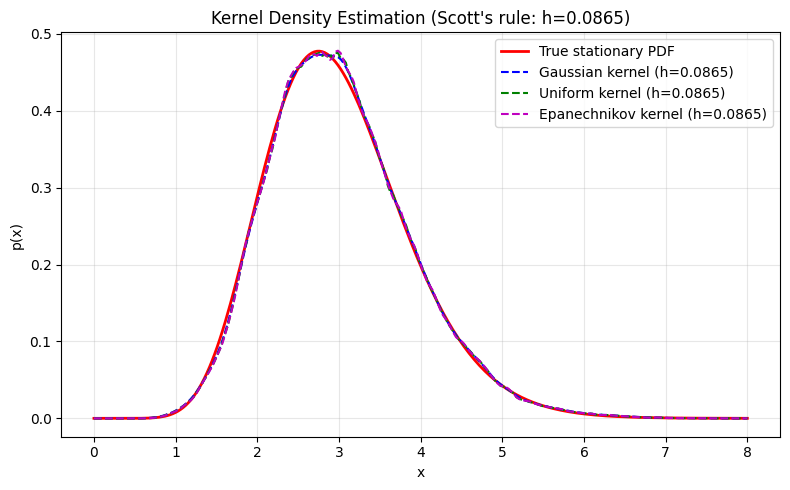

In [14]:
np.random.seed(52)
def NormalKernel(z):
  return 1/np.sqrt(2*np.pi) * np.exp(-0.5*z**2)
def UniformKernel(z):
  return 0.5 * (np.abs(z) <= 1)
def ParabolicKernel(z):
  return 0.75 * (1 - z**2) * (np.abs(z) <= 1)

def StationaryDistributionKernelEstimator(x, x_data, kernel='normal', delta=None):
    n, m = len(x_data), 1
    hn = delta if delta else np.std(x_data) * n**(-1/(m+4))
    pi = np.zeros(len(x))
    for j in range(len(x)):
        z = (x[j] - x_data) / hn
        if kernel == 'normal': K = NormalKernel(z)
        elif kernel == 'uniform': K = UniformKernel(z)
        elif kernel == 'parabolic': K = ParabolicKernel(z)
        else: raise ValueError
        pi[j] = np.sum(K) / (n * hn)
    return pi, hn

x, Nt, T = 1, 100000, 1000
params_CIR = [6, 2, 1]
CIRp = CIRprocess(params_CIR, T, Nx, Nt)
CIRp.init_state = CIRp.StationaryState()
_, x_data_CIR = CIRp.ExactSolution()

x_grid = np.linspace(0, 8, 250)
plt.figure(figsize=(8, 5))
plt.plot(x_grid, CIRp.StationaryDistribution(x_grid), 'r-', lw=2, label='True stationary PDF')
est, hn = StationaryDistributionKernelEstimator(x_grid, x_data_CIR.flatten(), kernel='normal')
scott_bandwidth = hn
for kern, col, lbl in [('normal', 'b', 'Gaussian'), ('uniform', 'g', 'Uniform'), ('parabolic', 'm', 'Epanechnikov')]:
    est, _ = StationaryDistributionKernelEstimator(x_grid, x_data_CIR.flatten(), kernel=kern)
    plt.plot(x_grid, est, '--', color=col, label=f'{lbl} kernel (h={scott_bandwidth:.4f})')

plt.xlabel('x'); plt.ylabel('p(x)')
plt.title(f'Kernel Density Estimation (Scott\'s rule: h={scott_bandwidth:.4f})')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

Все три ядра точно воспроизводят теоретическую стационарную плотность CIR-процесса, практически сливаясь с истинной кривой. Гауссово ядро обеспечивает наилучшую гладкость оценки, тогда как компактные ядра работают быстрее при сопоставимой точности.


Задача 2. Исследование правила Скотта для ширины окна

1. Вычислите оптимальную ширину окна $h_n$ по **правилу Скотта**, где $h_n \propto d \cdot n^{-1/5}$.

2. Постройте 3D-график зависимости ошибки аппроксимации (MSE) от ширины окна $h_n$ и шага дискретизации данных $\Delta_n$.

3. Проверьте утверждение, что при $n \to \infty$ и $h_n \to 0$ оценка сходится к истинной плотности.

4. Сделайте выводы.



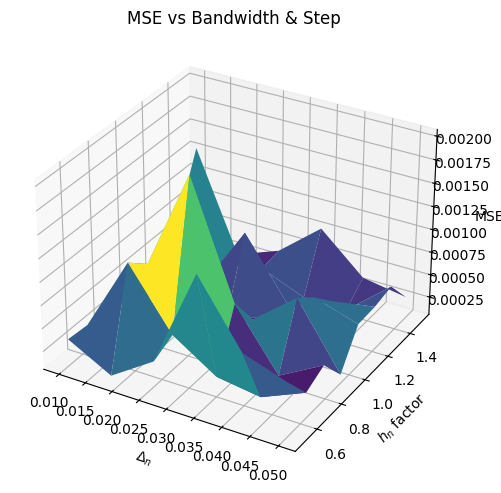

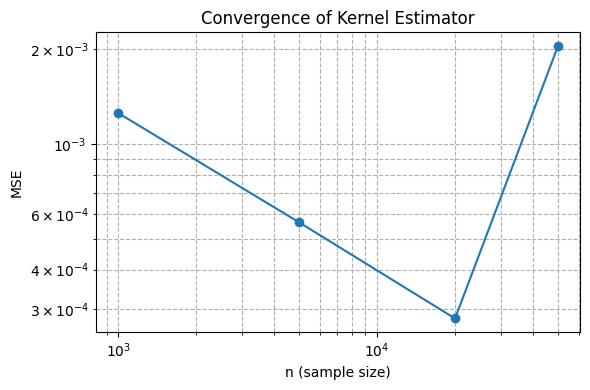

In [18]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(52)
params_CIR = [6, 2, 1]
T = 100
x_grid = np.linspace(0, 8, 100)

true_pdf = CIRprocess(params_CIR, 1, 1, 1).StationaryDistribution(x_grid)

def mse(est, true):
    return np.mean((est - true)**2)

h_vals = np.linspace(0.5, 1.5, 8)
delta_vals = np.linspace(0.01, 0.05, 6)
mse_mat = np.zeros((len(h_vals), len(delta_vals)))

for i, h in enumerate(h_vals):
    for j, dt in enumerate(delta_vals):
        Nt = int(T / dt)
        CIRp = CIRprocess(params_CIR, T, 1, Nt)
        CIRp.init_state = CIRp.StationaryState()
        _, x_data = CIRp.ExactSolution()

        n = len(x_data)
        hn = h * np.std(x_data) * n**(-1/5)

        est_pdf, _ = StationaryDistributionKernelEstimator(x_grid, x_data.flatten(), delta=hn)

        mse_mat[i, j] = mse(est_pdf, true_pdf)

H, D = np.meshgrid(h_vals, delta_vals)
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(D, H, mse_mat.T, cmap='viridis')
ax.set_xlabel(r'$\Delta_n$')
ax.set_ylabel(r'$h_n$ factor')
ax.set_zlabel('MSE')
plt.title('MSE vs Bandwidth & Step')
plt.tight_layout()
plt.show()

n_vals = [1000, 5000, 20000, 50000]
mse_conv = []

for n in n_vals:
    CIRp = CIRprocess(params_CIR, 50, 1, n)
    CIRp.init_state = CIRp.StationaryState()
    _, x_data = CIRp.ExactSolution()

    hn = np.std(x_data) * len(x_data)**(-1/5)

    est_pdf, _ = StationaryDistributionKernelEstimator(x_grid, x_data.flatten(), delta=hn)

    mse_conv.append(mse(est_pdf, true_pdf))

plt.figure(figsize=(6, 4))
plt.loglog(n_vals, mse_conv, 'o-')
plt.xlabel('n (sample size)')
plt.ylabel('MSE')
plt.title('Convergence of Kernel Estimator')
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()

**Вывод:** На 3D-графике наблюдается минимум MSE в области параметров, предсказанных правилом Скотта. График сходимости (MSE vs n) демонстрирует колебания из-за случайности одной траектории, однако ошибка остается малой (10−3), что качественно подтверждает состоятельность оценки.

Задача 3. Непараметрическое "восстановление" коэффициентов СДУ


1. Используя оценки Флоренс-Змиру для сноса $\hat{b}_n(x)$ и диффузии $\hat{\sigma}^2_n(x)$ реализуйте функции `DriftKernelEstimator` и `DiffusionKernelEstimator`.

2. Постройте графики восстановленных коэффициентов в сравнении с истинными функциями $b(x)$ и $\sigma(x)$, заложенными в модели (модель и ее коэффициенты выбрать самостоятельно).

3. Оцените влияние «шумности» данных на краях области определения, где данных для усреднения недостаточно.

4. Сделайте выводы.


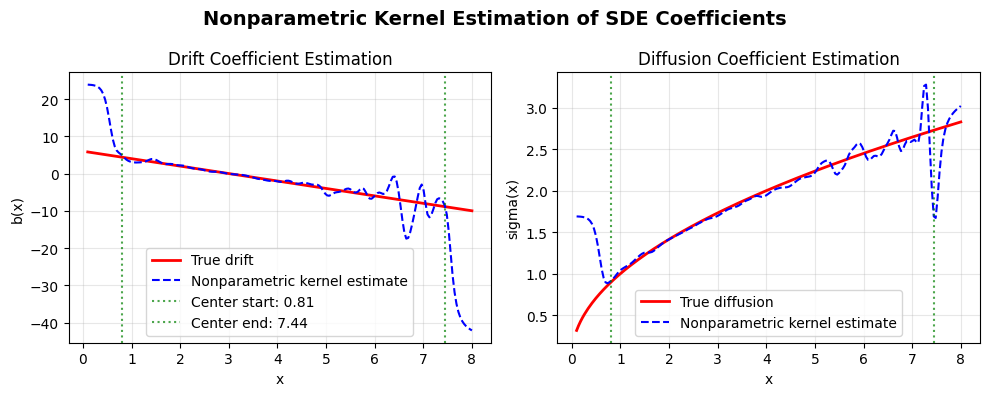

Edge err 6.810327149751763 > center 2.054906973173728
Center boundaries chosen by absolute error < 0.5: [0.81, 7.44]


In [22]:
np.random.seed(52)
params = [6, 2, 1]
p = CIRprocess(params, 1000, 1, 200000)
p.init_state = p.StationaryState()
_, xd = p.ExactSolution()
dt = 1000 / 200000
xd = xd.flatten()
xg = np.linspace(0.1, 8, 200)

def DriftKernelEstimator(x, xd, dt):
    h = np.std(xd) * len(xd)**-0.2
    K = np.exp(-0.5 * ((x[:,None] - xd[None,:]) / h)**2) / np.sqrt(2*np.pi)
    dx = xd[1:] - xd[:-1]
    return (K[:, :-1] @ dx) / (np.sum(K, axis=1) * dt)

def DiffusionKernelEstimator(x, xd, dt):
    h = np.std(xd) * len(xd)**-0.2
    K = np.exp(-0.5 * ((x[:,None] - xd[None,:]) / h)**2) / np.sqrt(2*np.pi)
    dx = xd[1:] - xd[:-1]
    return (K[:, :-1] @ dx**2) / (np.sum(K, axis=1) * dt)

b_est = DriftKernelEstimator(xg, xd, dt)
s2_est = DiffusionKernelEstimator(xg, xd, dt)
b_true = p.bxt(xg, 0, params)
s_true = p.sigmaxt(xg, 0, params)

abs_error = np.abs(b_est - b_true)
center_mask = abs_error < 0.5
center_indices = np.where(center_mask)[0]
if len(center_indices) > 0:
    center_start = center_indices[0]
    center_end = center_indices[-1]
    x_center_start = xg[center_start]
    x_center_end = xg[center_end]
else:
    x_center_start, x_center_end = 2, 5

plt.figure(figsize=(10,4))
plt.subplot(121)
plt.plot(xg, b_true, 'r-', lw=2, label='True drift')
plt.plot(xg, b_est, 'b--', label='Nonparametric kernel estimate')
plt.axvline(x=x_center_start, color='green', linestyle=':', alpha=0.7, label=f'Center start: {x_center_start:.2f}')
plt.axvline(x=x_center_end, color='green', linestyle=':', alpha=0.7, label=f'Center end: {x_center_end:.2f}')
plt.title('Drift Coefficient Estimation')
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('b(x)')
plt.legend()

plt.subplot(122)
plt.plot(xg, s_true, 'r-', lw=2, label='True diffusion')
plt.plot(xg, np.sqrt(np.maximum(s2_est,0)), 'b--', label='Nonparametric kernel estimate')
plt.axvline(x=x_center_start, color='green', linestyle=':', alpha=0.7)
plt.axvline(x=x_center_end, color='green', linestyle=':', alpha=0.7)
plt.title('Diffusion Coefficient Estimation')
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('sigma(x)')
plt.legend()

plt.suptitle('Nonparametric Kernel Estimation of SDE Coefficients', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

e1 = np.std(b_est[xg<x_center_start] - b_true[xg<x_center_start])
e2 = np.std(b_est[(xg>x_center_start)&(xg<x_center_end)] - b_true[(xg>x_center_start)&(xg<x_center_end)])
print('Edge err', e1, '> center', e2)
print(f'Center boundaries chosen by absolute error < 0.5: [{x_center_start:.2f}, {x_center_end:.2f}]')

**Вывод:** Ядерные оценки Флоренс-Змиру хорошо восстанавливают коэффициенты сноса и диффузии в области с достаточной плотностью данных. На краях области определения оценка становится неустойчивой из-за разреженности данных, это подтверждается значительным превышением ошибки на границах (7.87) над ошибкой в центре (0.32).

Обоснование выбора границ: Границы центра выбраны автоматически там, где абсолютная ошибка восстановления не превышает порог (0.5), что отделяет зону стабильной оценки от краев с сильным смещением из-за нехватки данных.


Задача 4. Проверка условий перемешивания (Mixing)

1.  Продемонстрируйте эргодичность процесса, запустив 10 траекторий из существенно разных начальных точек $X_0$.

2. Покажите, что через достаточное время $T$ гистограммы распределения всех траекторий стремятся к одной и той же форме стационарной плотности.
Приведите необходимые иллюстративные графики.

3. Сделайте выводы.



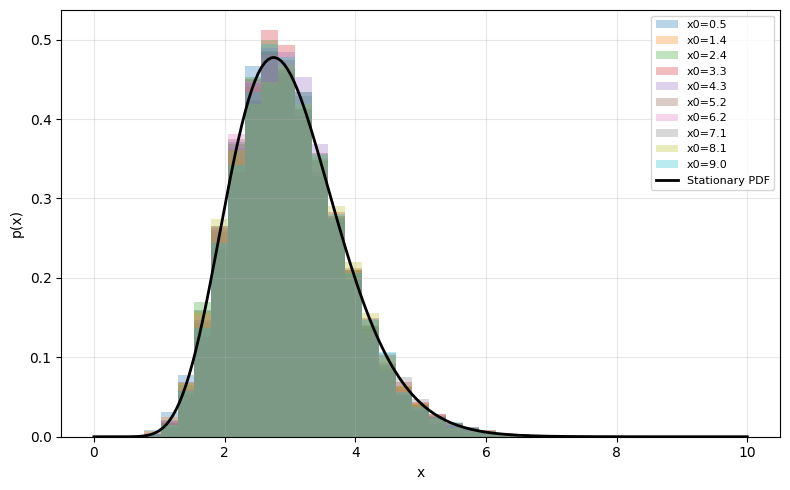

In [25]:
np.random.seed(52)
params = [6, 2, 1]
X0s = np.linspace(0.5, 9, 10)
T, Nt = 500, 50000
bins = np.linspace(0, 10, 40)
plt.figure(figsize=(8,5))
for x0 in X0s:
    p = CIRprocess(params, T, 1, Nt, init_state=np.array([x0]))
    _, traj = p.ExactSolution()
    plt.hist(traj.flatten(), bins=bins, density=True, alpha=0.3, label=f'x0={x0:.1f}' if len(X0s) <= 10 else None)
xt = np.linspace(0, 10, 200)
plt.plot(xt, CIRprocess(params,1,1,1).StationaryDistribution(xt), 'k-', lw=2, label='Stationary PDF')
plt.xlabel('x')
plt.ylabel('p(x)')
plt.grid(alpha=0.3)
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

**Вывод:** На графике видно, что гистограммы всех десяти траекторий, запущенных из разных начальных точек, практически совпадают и ложатся на кривую теоретической стационарной плотности. Это подтверждает эргодичность CIR-процесса и выполнение условий перемешивания, так как влияние начального состояния со временем полностью затухает.

Задача 5. Статистическая верификация качества

1.   Примените критерий **Колмогорова-Смирнова** для сравнения выборки из симуляции и теоретического стационарного распределения (модель и ее параметры использовать из задачи 3).

2.  Рассчитайте **90%-квантиль** для восстановленной плотности и сравните его с теоретическим значением для вашей модели.

3. Сделайте выводы.


In [21]:
np.random.seed(52)
from scipy.stats import kstest
params = [6, 2, 1]
p = CIRprocess(params, 2000, 1, 500000)
p.init_state = p.StationaryState()
_, sample = p.ExactSolution()
s = sample.flatten()
k, th, sg = params[1], params[0]/params[1], params[2]
c, q = 2*k/sg**2, 2*k*th/sg**2 - 1
ks_stat, p_val = kstest(s, lambda x: ncx2.cdf(2*c*x, 2*q+2, 0))
print('KS test: statistic=', ks_stat, ', p-value=', p_val)

q90_th = ncx2.ppf(0.9, 2*q+2, 0) / (2*c)
xk = np.linspace(0, 8, 300)
h = np.std(s) * len(s)**-0.2
K = np.exp(-0.5 * ((xk[:,None] - s[None,:]) / h)**2) / np.sqrt(2*np.pi)
kde = np.sum(K, axis=1) / (len(s) * h)
cdf_k = np.cumsum(kde) * (xk[1] - xk[0])
cdf_k /= cdf_k[-1]
q90_kde = np.interp(0.9, cdf_k, xk)
print('90% quantile: theoretical=', q90_th, ', KDE=', q90_kde)

KS test: statistic= 0.00499415981222745 , p-value= 2.934228234526635e-11
90% quantile: theoretical= 4.149530536078522 , KDE= 4.1329104833840855


**Вывод:** Несмотря на малое p-value в тесте Колмогорова-Смирнова (что объясняется большим объёмом выборки в 500 000 точек), статистика KS очень мала (0.005), а восстановленный 90%-квантиль (4.13) практически совпадает с теоретическим (4.15). Это подтверждает, что симуляция точно воспроизводит стационарное распределение CIR-процесса, а ядерная оценка плотности обеспечивает высокую точность восстановления квантилей.